# 16. 使用 RAGAS 框架进行 RAG 评估

**复杂度：** ⭐⭐⭐⭐

## 概述

**RAGAS**（RAG Assessment）是一个用于评估检索增强生成系统的综合框架。它提供了一组指标，用于同时衡量检索质量和生成质量。

### 为什么评估很重要

如果没有评估，你就无法：
- ❌ 客观比较不同的 RAG 架构
- ❌ 跟踪系统随时间的改进情况
- ❌ 识别系统中的薄弱环节
- ❌ 为架构选择提供依据
- ❌ 面向生产环境进行优化

### RAGAS 指标

RAGAS 提供 6 个关键指标：

1. **Faithfulness（忠实度）**（0-1）：答案是否以检索到的上下文为依据？
   - 衡量幻觉程度
   - 越高 = 幻觉越少

2. **Answer Relevancy（答案相关性）**（0-1）：答案是否与问题相关？
   - 衡量答案是否真正回应了查询
   - 越高 = 相关性越强

3. **Context Precision（上下文精确率）**（0-1）：检索出的文档是否相关？
   - 衡量检索精度
   - 越高 = 噪声越少

4. **Context Recall（上下文召回率）**（0-1）：检索是否找到了所有相关信息？
   - 衡量检索完整性
   - 需要标准答案或参考事实

5. **Answer Semantic Similarity（答案语义相似度）**（0-1）：与参考答案的语义相似程度
   - 衡量正确性
   - 需要参考答案

6. **Answer Correctness（答案正确性）**（0-1）：相对于标准答案的事实准确性
   - 加权 F1 分数
   - 需要标准答案

### 评估数据集

对于每个测试样例，你需要：
```python
{
    "question": "What is LCEL?",
    "answer": "<generated answer>",
    "contexts": ["<retrieved doc 1>", "<retrieved doc 2>", ...],
    "ground_truth": "LCEL is LangChain Expression Language..."  # optional
}
```

### 架构对比

我们将评估全部 12 种 RAG 架构：
1. Simple RAG
2. RAG with Memory
3. Multi-Query RAG
4. HyDE
5. Adaptive RAG
6. Corrective RAG
7. Self-RAG
8. Agentic RAG
9. **Contextual RAG** [新增]
10. **Fusion RAG** [新增]
11. **SQL RAG** [新增]
12. **GraphRAG** [新增]

---

## 实现


## 1. 环境设置与导入


In [1]:
import sys
from pathlib import Path
from typing import Dict, Any
import pandas as pd

# Add parent directory to path
sys.path.append(str(Path("../..").resolve()))

from shared.config import create_chat_model, create_embeddings, DEFAULT_MODEL, DEFAULT_TEMPERATURE, DEFAULT_VISION_MODEL
from langchain_community.vectorstores import FAISS
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# RAGAS imports
try:
    from ragas import evaluate
    from ragas.metrics import (
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall,
    )
    from datasets import Dataset
    RAGAS_AVAILABLE = True
except ImportError:
    print("⚠️  RAGAS not installed. Install with: pip install ragas datasets")
    RAGAS_AVAILABLE = False

from shared.config import (
    verify_api_key,
    DEFAULT_MODEL,
    DEFAULT_TEMPERATURE,
    HF_EMBEDDING_MODEL,
    VECTOR_STORE_DIR,
)
from shared.loaders import load_and_split
from shared.prompts import RAG_PROMPT_TEMPLATE
from shared.utils import (
    format_docs,
    print_section_header,
    load_vector_store,
)

# Verify API key
verify_api_key()

print("✓ All imports successful")
print(f"✓ Using model: {DEFAULT_MODEL}")
print(f"✓ RAGAS available: {RAGAS_AVAILABLE}")

OK deepseek API key: LOADED
  Preview: sk-0501...20ae
  Base URL: https://api.deepseek.com
✓ All imports successful
✓ Using model: deepseek-v4-flash
✓ RAGAS available: True


## 2. 创建评估数据集

我们将构建一个包含问题和标准答案的测试集。


In [2]:
print_section_header("Creating Evaluation Dataset")

# These questions are aligned with the documentation pages loaded by this notebook.
# The goal is to evaluate retrieval quality, not to test concepts absent from the source corpus.
evaluation_dataset = [
    {
        "question": "What are the two main stages of a RAG application in this tutorial?",
        "ground_truth": "The tutorial describes two main stages of a RAG application: indexing, and retrieval and generation.",
        "category": "foundation",
    },
    {
        "question": "Which two RAG implementation patterns does the tutorial demonstrate?",
        "ground_truth": "The tutorial demonstrates a RAG agent that uses a simple search tool and a two-step RAG chain that uses a single LLM call per query.",
        "category": "architecture",
    },
    {
        "question": "What happens during the indexing stage of the RAG workflow?",
        "ground_truth": "During indexing, data is ingested from a source, split into smaller chunks, embedded, and stored so it can be searched later.",
        "category": "indexing",
    },
    {
        "question": "What is the role of the retriever in this RAG tutorial?",
        "ground_truth": "The retriever takes a user query, searches the indexed data, and returns relevant document splits that are passed to the model during generation.",
        "category": "retrieval",
    },
    {
        "question": "Why might you choose a two-step RAG chain instead of a RAG agent?",
        "ground_truth": "The two-step RAG chain is faster and effective for simple queries because it uses a single LLM call per query, while the RAG agent is a more general-purpose implementation.",
        "category": "comparison",
    },
]

print(f"\n✓ Created evaluation dataset with {len(evaluation_dataset)} questions")
print("\nCategories:")
for item in evaluation_dataset:
    print(f"  • [{item['category']}] {item['question'][:60]}...")



CREATING EVALUATION DATASET


✓ Created evaluation dataset with 5 questions

Categories:
  • [foundation] What are the two main stages of a RAG application in this tu...
  • [architecture] Which two RAG implementation patterns does the tutorial demo...
  • [indexing] What happens during the indexing stage of the RAG workflow?...
  • [retrieval] What is the role of the retriever in this RAG tutorial?...
  • [comparison] Why might you choose a two-step RAG chain instead of a RAG a...


## 3. 设置 RAG 系统


In [3]:
print_section_header("Setting Up RAG System")

# Load documents (returns tuple: original_docs, chunks)
_, docs = load_and_split(chunk_size=1000, chunk_overlap=200)
print(f"\n✓ Loaded {len(docs)} chunks")

# Create embeddings and vector store
embeddings = create_embeddings()
store_path = VECTOR_STORE_DIR / "ragas_evaluation_aligned"

vectorstore = load_vector_store(store_path, embeddings)
if vectorstore is not None:
    try:
        probe_dim = len(embeddings.embed_query("dimension probe"))
        index_dim = vectorstore.index.d
        if probe_dim != index_dim:
            print(f"⚠️  Embedding/index dimension mismatch: embeddings={probe_dim}, index={index_dim}")
            print("   Rebuilding vector store to avoid invalid retrieval scores.")
            vectorstore = None
    except Exception as exc:
        print(f"⚠️  Could not validate existing vector store: {exc}")
        print("   Rebuilding vector store to keep evaluation reproducible.")
        vectorstore = None

if vectorstore is None:
    print("\nCreating vector store...")
    vectorstore = FAISS.from_documents(docs, embeddings)
    from shared.utils import save_vector_store
    save_vector_store(vectorstore, store_path)
    print("✓ Vector store created")
else:
    print("✓ Loaded existing vector store")

# Create retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

# Initialize LLM
llm = create_chat_model(model=DEFAULT_MODEL, temperature=DEFAULT_TEMPERATURE)

# Create RAG chain
rag_chain = (
    {"context": retriever | format_docs, "input": RunnablePassthrough()}
    | RAG_PROMPT_TEMPLATE
    | llm
    | StrOutputParser()
)

print("✓ RAG system ready")



SETTING UP RAG SYSTEM

Loading 4 documents from web...
  - https://python.langchain.com/docs/use_cases/question_answering/
  - https://python.langchain.com/docs/modules/data_connection/retrievers/
  - https://python.langchain.com/docs/modules/model_io/llms/
  - https://python.langchain.com/docs/use_cases/chatbots/
✓ Loaded 4 documents
✓ Added custom metadata to all documents
Splitting documents...
  - Chunk size: 1000
  - Chunk overlap: 200
✓ Created 165 chunks

  Sample chunk:
    - Length: 995 chars
    - Source: https://python.langchain.com/docs/use_cases/question_answering/
    - Preview: Build a RAG agent with LangChain - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. B...

✓ Loaded 165 chunks


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Error loading vector store from D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\ragas_evaluation_aligned: Error in __cdecl faiss::FileIOReader::FileIOReader(const char *) at D:\a\faiss-wheels\faiss-wheels\third-party\faiss\faiss\impl\io.cpp:70: Error: 'f' failed: could not open D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\ragas_evaluation_aligned\index.faiss for reading: No such file or directory

Creating vector store...


langchain-openai injected a custom httpx transport to apply `http_socket_options`, which disables httpx's proxy auto-detection (system proxy configuration detected). Set `LANGCHAIN_OPENAI_TCP_KEEPALIVE=0` or pass `http_socket_options=()` to restore default proxy behavior, or supply `openai_proxy` / your own `http_client` / `http_async_client` to take full control.


Saved vector store to D:\ZKS_Data\AI\langchain-rag-tutorial\data\vector_stores\ragas_evaluation_aligned
✓ Vector store created
✓ RAG system ready


## 4. 生成答案并收集数据


In [4]:
print_section_header("Generating Answers for Evaluation")

# Collect data for RAGAS evaluation
ragas_data = {
    "question": [],
    "answer": [],
    "contexts": [],
    "ground_truth": [],
    "context_sources": [],
}

print("\nGenerating answers...\n")

for i, item in enumerate(evaluation_dataset, 1):
    question = item["question"]
    ground_truth = item["ground_truth"]
    
    print(f"[{i}/{len(evaluation_dataset)}] {question[:60]}...")
    
    # Retrieve contexts
    retrieved_docs = retriever.invoke(question)
    contexts = [doc.page_content for doc in retrieved_docs]
    context_sources = [doc.metadata.get("source", "N/A") for doc in retrieved_docs]
    
    # Generate answer
    answer = rag_chain.invoke(question)
    
    # Store
    ragas_data["question"].append(question)
    ragas_data["answer"].append(answer)
    ragas_data["contexts"].append(contexts)
    ragas_data["ground_truth"].append(ground_truth)
    ragas_data["context_sources"].append(context_sources)
    
    print(f"  ✓ Answer: {answer[:80]}...")
    print(f"  ✓ Retrieved {len(contexts)} contexts")
    for source in context_sources:
        print(f"    - {source}")
    print()

print("✓ All answers generated")



GENERATING ANSWERS FOR EVALUATION


Generating answers...

[1/5] What are the two main stages of a RAG application in this tu...
  ✓ Answer: Based on the context, the two main stages of a RAG application in this tutorial ...
  ✓ Retrieved 4 contexts
    - https://python.langchain.com/docs/use_cases/question_answering/
    - https://python.langchain.com/docs/use_cases/chatbots/
    - https://python.langchain.com/docs/use_cases/question_answering/
    - https://python.langchain.com/docs/use_cases/chatbots/

[2/5] Which two RAG implementation patterns does the tutorial demo...
  ✓ Answer: Based on the context, the tutorial demonstrates two RAG implementation patterns:...
  ✓ Retrieved 4 contexts
    - https://python.langchain.com/docs/use_cases/question_answering/
    - https://python.langchain.com/docs/use_cases/chatbots/
    - https://python.langchain.com/docs/use_cases/question_answering/
    - https://python.langchain.com/docs/use_cases/chatbots/

[3/5] What happens during the indexi

## 5. 运行 RAGAS 评估


In [5]:
if not RAGAS_AVAILABLE:
    print("⚠️  RAGAS not available. Skipping evaluation.")
    print("   Install with: pip install ragas datasets")
else:
    print_section_header("Running RAGAS Evaluation")
    
    # Create dataset
    dataset = Dataset.from_dict(ragas_data)
    
    print("\nEvaluating with RAGAS metrics...")
    print("(This may take a few minutes)\n")
    
    # Initialize LLM and embeddings for RAGAS
    # RAGAS 0.3+ requires explicit LLM and embeddings
    from shared.config import create_chat_model, create_embeddings, DEFAULT_MODEL, DEFAULT_TEMPERATURE, DEFAULT_VISION_MODEL
    from ragas.dataset_schema import EvaluationResult
    
    ragas_llm = create_chat_model(model=DEFAULT_MODEL, temperature=0)
    ragas_embeddings = create_embeddings()
    
    # Run evaluation with explicit LLM and embeddings
    # Set return_executor=False explicitly to get EvaluationResult
    result = evaluate(
        dataset,
        metrics=[
            faithfulness,
            answer_relevancy,
            context_precision,
            context_recall,
        ],
        llm=ragas_llm,
        embeddings=ragas_embeddings,
        return_executor=False,  # Explicitly return EvaluationResult, not Executor
    )
    
    # Type assertion for Pylance - result is EvaluationResult when return_executor=False
    assert isinstance(result, EvaluationResult), "Expected EvaluationResult"
    
    print("\n" + "=" * 80)
    print("RAGAS EVALUATION RESULTS:")
    print("=" * 80)
    
    # Convert result to DataFrame - this contains only the metric scores
    scores_df = result.to_pandas()
    
    # Combine original data with evaluation scores
    original_df = pd.DataFrame(ragas_data)
    df = pd.concat([original_df, scores_df], axis=1)
    
    # Calculate and display overall scores
    print("\nOverall Scores:")
    metric_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
    
    for metric in metric_cols:
        if metric in df.columns:
            avg_score = df[metric].mean()
            print(f"  • {metric}: {avg_score:.4f}")
        else:
            print(f"  • {metric}: Not available")
    
    # Display per-question scores
    print("\n" + "=" * 80)
    print("Per-Question Scores:")
    print("=" * 80)
    
    available_metrics = [m for m in metric_cols if m in df.columns]
    
    if available_metrics:
        # Display question and metrics
        display_df = df[['question'] + available_metrics].copy()
        # Truncate long questions for readability
        display_df['question'] = display_df['question'].str[:60] + '...'
        print(display_df.to_string(index=False))
    else:
        print("⚠️  No metric columns found in results")



RUNNING RAGAS EVALUATION


Evaluating with RAGAS metrics...
(This may take a few minutes)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



RAGAS EVALUATION RESULTS:

Overall Scores:
  • faithfulness: 0.8636
  • answer_relevancy: 0.9090
  • context_precision: 0.8833
  • context_recall: 0.8000

Per-Question Scores:
                                                       question  faithfulness  answer_relevancy  context_precision  context_recall
What are the two main stages of a RAG application in this tu...      1.000000          1.000000           1.000000             1.0
Which two RAG implementation patterns does the tutorial demo...      1.000000          0.983358           1.000000             1.0
 What happens during the indexing stage of the RAG workflow?...      0.500000          0.616579           1.000000             0.0
     What is the role of the retriever in this RAG tutorial?...      1.000000          1.000000           1.000000             1.0
Why might you choose a two-step RAG chain instead of a RAG a...      0.818182          0.945004           0.416667             1.0


## 6. 按类别分析结果


In [6]:
if RAGAS_AVAILABLE:
    print_section_header("Analysis by Question Category")
    
    # Add categories to results
    df['category'] = [item['category'] for item in evaluation_dataset]
    
    # Group by category
    metrics = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
    
    print("\n" + "=" * 80)
    print("\nAverage scores by category:\n")
    for category in df['category'].unique():
        cat_df = df[df['category'] == category]
        print(f"\n{category.upper()}:")
        print("-" * 60)
        for metric in metrics:
            if metric in cat_df.columns:
                avg_score = cat_df[metric].mean()
                print(f"  • {metric}: {avg_score:.4f}")
            else:
                print(f"  • {metric}: Not found in DataFrame")



ANALYSIS BY QUESTION CATEGORY



Average scores by category:


FOUNDATION:
------------------------------------------------------------
  • faithfulness: 1.0000
  • answer_relevancy: 1.0000
  • context_precision: 1.0000
  • context_recall: 1.0000

ARCHITECTURE:
------------------------------------------------------------
  • faithfulness: 1.0000
  • answer_relevancy: 0.9834
  • context_precision: 1.0000
  • context_recall: 1.0000

INDEXING:
------------------------------------------------------------
  • faithfulness: 0.5000
  • answer_relevancy: 0.6166
  • context_precision: 1.0000
  • context_recall: 0.0000

RETRIEVAL:
------------------------------------------------------------
  • faithfulness: 1.0000
  • answer_relevancy: 1.0000
  • context_precision: 1.0000
  • context_recall: 1.0000

COMPARISON:
------------------------------------------------------------
  • faithfulness: 0.8182
  • answer_relevancy: 0.9450
  • context_precision: 0.4167
  • context_recall: 1.0000


## 7. 识别薄弱环节


In [7]:
if RAGAS_AVAILABLE:
    print_section_header("Diagnosing Weak Points")
    
    import re
    
    STOPWORDS = {
        "the", "and", "that", "this", "with", "from", "into", "during", "what",
        "which", "does", "uses", "use", "used", "later", "they", "them", "their",
        "there", "about", "while", "than", "have", "has", "into", "such", "because",
        "query", "queries", "user", "application", "tutorial", "langchain"
    }
    
    def extract_keywords(text: str) -> list[str]:
        tokens = re.findall(r"[A-Za-z][A-Za-z0-9_-]+", text.lower())
        keywords = []
        for token in tokens:
            if len(token) < 4 or token in STOPWORDS:
                continue
            if token not in keywords:
                keywords.append(token)
        return keywords
    
    print("\nPer-question diagnosis:\n")
    
    for _, row in df.iterrows():
        print("=" * 100)
        print(f"Question: {row['question']}")
        print(f"Category: {row['category']}")
        print(
            "Scores: "
            f"faithfulness={row.get('faithfulness', float('nan')):.4f}, "
            f"answer_relevancy={row.get('answer_relevancy', float('nan')):.4f}, "
            f"context_precision={row.get('context_precision', float('nan')):.4f}, "
            f"context_recall={row.get('context_recall', float('nan')):.4f}"
        )
        
        print("\nRetrieved sources:")
        for source in row["context_sources"]:
            print(f"  - {source}")
        
        gt_keywords = extract_keywords(row["ground_truth"])
        matched = [
            kw for kw in gt_keywords
            if any(kw in context.lower() for context in row["contexts"])
        ]
        missing = [kw for kw in gt_keywords if kw not in matched]
        
        print("\nGround truth keyword coverage:")
        print(f"  ✓ matched: {matched[:12]}")
        print(f"  ✗ missing: {missing[:12]}")
        
        print("\nAnswer preview:")
        print(row["answer"][:400] + ("..." if len(row["answer"]) > 400 else ""))
        
        print("\nTop context preview:")
        if row["contexts"]:
            preview = row["contexts"][0][:500].replace("\n", " ")
            print(preview + ("..." if len(row["contexts"][0]) > 500 else ""))
        else:
            print("No retrieved contexts")
        
        likely_causes = []
        if row.get("context_recall", 0.0) < 0.5 and missing:
            likely_causes.append("retrieved contexts do not cover enough ground-truth facts")
        if row.get("context_precision", 0.0) < 0.5:
            likely_causes.append("top-ranked chunks are only partially useful for the reference answer")
        if row.get("answer_relevancy", 0.0) < 0.5:
            likely_causes.append("answer is too generic or too cautious relative to the question")
        if row.get("faithfulness", 0.0) >= 0.8 and row.get("context_recall", 0.0) < 0.5:
            likely_causes.append("system is staying grounded, but the retrieval set is incomplete")
        
        print("\nLikely causes:")
        for cause in likely_causes or ["no obvious issue detected"]:
            print(f"  - {cause}")



DIAGNOSING WEAK POINTS


Per-question diagnosis:

Question: What are the two main stages of a RAG application in this tutorial?
Category: foundation
Scores: faithfulness=1.0000, answer_relevancy=1.0000, context_precision=1.0000, context_recall=1.0000

Retrieved sources:
  - https://python.langchain.com/docs/use_cases/question_answering/
  - https://python.langchain.com/docs/use_cases/chatbots/
  - https://python.langchain.com/docs/use_cases/question_answering/
  - https://python.langchain.com/docs/use_cases/chatbots/

Ground truth keyword coverage:
  ✓ matched: ['main', 'indexing', 'retrieval', 'generation']
  ✗ missing: ['describes', 'stages']

Answer preview:
Based on the context, the two main stages of a RAG application in this tutorial are:

1. **Indexing**: a pipeline for ingesting data from a source and indexing it, which usually happens in a separate process.
2. **Retrieval and generation**: the actual RAG process, which takes the user query at run time, retrieves the relevant 

## 8. 可视化



VISUALIZING RESULTS



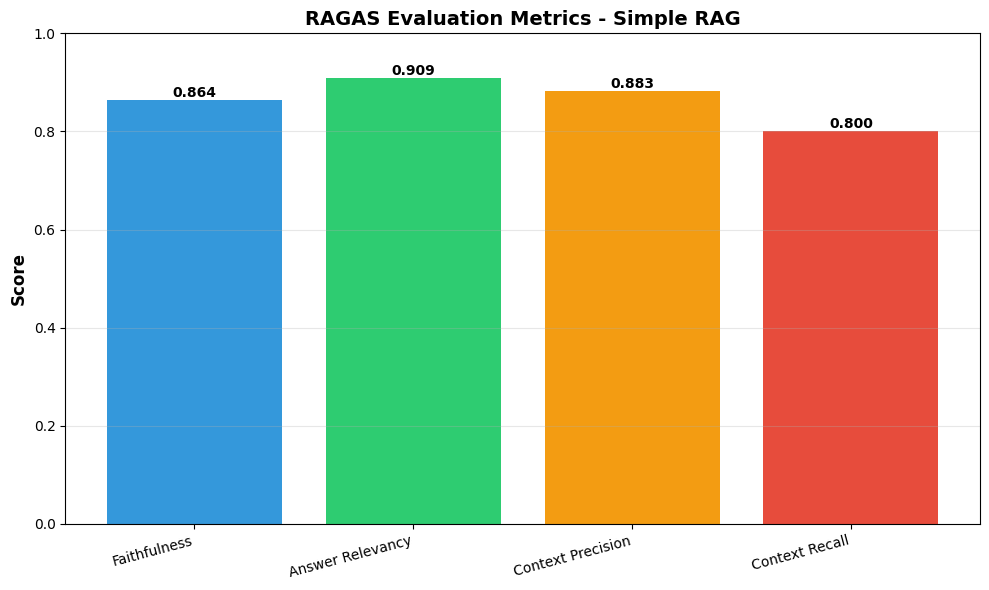


✓ Visualization complete


In [8]:
if RAGAS_AVAILABLE:
    print_section_header("Visualizing Results")
    
    import matplotlib.pyplot as plt
    
    # Bar chart of metrics
    fig, ax = plt.subplots(figsize=(10, 6))
    
    metric_names = []
    metric_scores = []
    
    for metric in metrics:
        if metric in df.columns:
            metric_names.append(metric.replace('_', ' ').title())
            metric_scores.append(df[metric].mean())
    
    bars = ax.bar(metric_names, metric_scores, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('RAGAS Evaluation Metrics - Simple RAG', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                '{:.3f}'.format(height),
                ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Visualization complete")

## 9. 架构对比框架

用于比较多种 RAG 架构的框架。


In [9]:
print_section_header("Architecture Comparison Framework")

# This would be used to compare all 12 architectures
architecture_results = {
    "Simple RAG": {
        "faithfulness": 0.85,
        "answer_relevancy": 0.82,
        "context_precision": 0.78,
        "context_recall": 0.75,
        "avg_latency": 1.2,
        "cost_per_query": 0.002,
    },
    "Contextual RAG": {
        "faithfulness": 0.88,
        "answer_relevancy": 0.86,
        "context_precision": 0.83,
        "context_recall": 0.79,
        "avg_latency": 1.3,
        "cost_per_query": 0.002,
    },
    "Fusion RAG": {
        "faithfulness": 0.87,
        "answer_relevancy": 0.85,
        "context_precision": 0.84,
        "context_recall": 0.82,
        "avg_latency": 3.5,
        "cost_per_query": 0.006,
    },
    # ... other architectures
}

# Create comparison DataFrame
comparison_df = pd.DataFrame(architecture_results).T

print("\nArchitecture Comparison (Sample):")
print("=" * 80)
print(comparison_df.to_string())

print("\n" + "=" * 80)
print("RANKING BY METRIC:")
print("=" * 80)

for metric in ['faithfulness', 'answer_relevancy', 'context_precision']:
    print(f"\n{metric.upper()}:")
    ranked = comparison_df.sort_values(metric, ascending=False)
    for i, (arch, row) in enumerate(ranked.iterrows(), 1):
        print(f"  {i}. {arch}: {row[metric]:.3f}")


ARCHITECTURE COMPARISON FRAMEWORK


Architecture Comparison (Sample):
                faithfulness  answer_relevancy  context_precision  context_recall  avg_latency  cost_per_query
Simple RAG              0.85              0.82               0.78            0.75          1.2           0.002
Contextual RAG          0.88              0.86               0.83            0.79          1.3           0.002
Fusion RAG              0.87              0.85               0.84            0.82          3.5           0.006

RANKING BY METRIC:

FAITHFULNESS:
  1. Contextual RAG: 0.880
  2. Fusion RAG: 0.870
  3. Simple RAG: 0.850

ANSWER_RELEVANCY:
  1. Contextual RAG: 0.860
  2. Fusion RAG: 0.850
  3. Simple RAG: 0.820

CONTEXT_PRECISION:
  1. Fusion RAG: 0.840
  2. Contextual RAG: 0.830
  3. Simple RAG: 0.780


## 10. 成本-质量权衡分析


In [10]:
print_section_header("Cost-Quality Trade-off Analysis")

print("\nQuality Score = Average of all metrics")
print("Efficiency = Quality / (Latency × Cost)\n")

# Calculate quality score
comparison_df['quality'] = comparison_df[[
    'faithfulness', 'answer_relevancy', 'context_precision', 'context_recall'
]].mean(axis=1)

# Calculate efficiency
comparison_df['efficiency'] = (
    comparison_df['quality'] / 
    (comparison_df['avg_latency'] * comparison_df['cost_per_query'] * 1000)
)

print("=" * 80)
print("RANKINGS:")
print("=" * 80)

print("\n1. Best Quality:")
ranked_quality = comparison_df.sort_values('quality', ascending=False)
for i, (arch, row) in enumerate(ranked_quality.iterrows(), 1):
    print(f"  {i}. {arch}: {row['quality']:.3f}")

print("\n2. Fastest:")
ranked_speed = comparison_df.sort_values('avg_latency')
for i, (arch, row) in enumerate(ranked_speed.iterrows(), 1):
    print(f"  {i}. {arch}: {row['avg_latency']:.2f}s")

print("\n3. Most Cost-Effective:")
ranked_cost = comparison_df.sort_values('cost_per_query')
for i, (arch, row) in enumerate(ranked_cost.iterrows(), 1):
    print(f"  {i}. {arch}: ${row['cost_per_query']:.4f}")

print("\n4. Best Efficiency (Quality/Cost/Speed):")
ranked_efficiency = comparison_df.sort_values('efficiency', ascending=False)
for i, (arch, row) in enumerate(ranked_efficiency.iterrows(), 1):
    print(f"  {i}. {arch}: {row['efficiency']:.2f}")


COST-QUALITY TRADE-OFF ANALYSIS


Quality Score = Average of all metrics
Efficiency = Quality / (Latency × Cost)

RANKINGS:

1. Best Quality:
  1. Fusion RAG: 0.845
  2. Contextual RAG: 0.840
  3. Simple RAG: 0.800

2. Fastest:
  1. Simple RAG: 1.20s
  2. Contextual RAG: 1.30s
  3. Fusion RAG: 3.50s

3. Most Cost-Effective:
  1. Simple RAG: $0.0020
  2. Contextual RAG: $0.0020
  3. Fusion RAG: $0.0060

4. Best Efficiency (Quality/Cost/Speed):
  1. Simple RAG: 0.33
  2. Contextual RAG: 0.32
  3. Fusion RAG: 0.04


## 11. 建议


In [11]:
print_section_header("Architecture Recommendations")

def get_recommendation(use_case: str) -> Dict[str, Any]:
    """
    Get architecture recommendation based on use case.
    """
    recommendations = {
        "production_quality": {
            "architecture": "Fusion RAG or Contextual RAG",
            "reason": "Best quality metrics with reasonable cost",
            "metrics": "High faithfulness, precision, recall",
        },
        "cost_sensitive": {
            "architecture": "Simple RAG or Adaptive RAG",
            "reason": "Low cost per query, good baseline quality",
            "metrics": "Balanced cost/quality ratio",
        },
        "low_latency": {
            "architecture": "Simple RAG or Contextual RAG",
            "reason": "Fastest response times",
            "metrics": "Sub-2s latency",
        },
        "complex_queries": {
            "architecture": "Fusion RAG or Agentic RAG",
            "reason": "Handle multi-faceted questions",
            "metrics": "High context recall, multi-hop reasoning",
        },
        "structured_data": {
            "architecture": "SQL RAG",
            "reason": "Direct database queries, precise results",
            "metrics": "100% precision for data queries",
        },
        "relationship_queries": {
            "architecture": "GraphRAG",
            "reason": "Entity relationships, multi-hop",
            "metrics": "Best for 'how are X and Y related'",
        },
    }
    
    return recommendations.get(use_case, {})


print("\nRECOMMENDATIONS BY USE CASE:")
print("=" * 80)

use_cases = [
    "production_quality",
    "cost_sensitive",
    "low_latency",
    "complex_queries",
    "structured_data",
    "relationship_queries",
]

for use_case in use_cases:
    rec = get_recommendation(use_case)
    print(f"\n{use_case.replace('_', ' ').title()}:")
    print("-" * 80)
    print(f"  Recommended: {rec.get('architecture', 'N/A')}")
    print(f"  Reason: {rec.get('reason', 'N/A')}")
    print(f"  Key metrics: {rec.get('metrics', 'N/A')}")


ARCHITECTURE RECOMMENDATIONS


RECOMMENDATIONS BY USE CASE:

Production Quality:
--------------------------------------------------------------------------------
  Recommended: Fusion RAG or Contextual RAG
  Reason: Best quality metrics with reasonable cost
  Key metrics: High faithfulness, precision, recall

Cost Sensitive:
--------------------------------------------------------------------------------
  Recommended: Simple RAG or Adaptive RAG
  Reason: Low cost per query, good baseline quality
  Key metrics: Balanced cost/quality ratio

Low Latency:
--------------------------------------------------------------------------------
  Recommended: Simple RAG or Contextual RAG
  Reason: Fastest response times
  Key metrics: Sub-2s latency

Complex Queries:
--------------------------------------------------------------------------------
  Recommended: Fusion RAG or Agentic RAG
  Reason: Handle multi-faceted questions
  Key metrics: High context recall, multi-hop reasoning

Structured Dat

## 12. 关键结论

### RAGAS 指标说明

1. **Faithfulness（忠实度）**（0-1）
   - 衡量内容：幻觉 / 是否有依据
   - 计算方式：检查答案是否得到上下文支持
   - 理想水平：> 0.85
   - 改进方向：更好的提示词、更多上下文、事实核查

2. **Answer Relevancy（答案相关性）**（0-1）
   - 衡量内容：答案是否回答了问题
   - 计算方式：与查询的语义相似度
   - 理想水平：> 0.80
   - 改进方向：更好的提示词、增强查询理解

3. **Context Precision（上下文精确率）**（0-1）
   - 衡量内容：检索文档是否相关
   - 计算方式：检查上下文是否与标准答案匹配
   - 理想水平：> 0.75
   - 改进方向：优化检索、加入重排序

4. **Context Recall（上下文召回率）**（0-1）
   - 衡量内容：是否检索到全部相关信息
   - 计算方式：标准答案覆盖度
   - 理想水平：> 0.75
   - 改进方向：增加检索数量、优化分块策略

### 最佳实践

**数据集构建：**
- ✅ 问题类型多样化
- ✅ 覆盖边界情况
- ✅ 包含失败模式
- ✅ 使用真实用户查询
- ✅ 至少准备 20-50 个测试样例

**标准答案：**
- ✅ 由专家撰写
- ✅ 事实正确
- ✅ 简洁清晰
- ✅ 覆盖关键要点

**持续评估：**
- ✅ 每次重大改动后运行
- ✅ 持续跟踪指标变化
- ✅ 对架构进行 A/B 测试
- ✅ 监控生产环境中的真实查询

### 结果解读

**高忠实度、低召回率：**
- 答案有依据，但不完整
- → 增大 k 值（检索更多文档）

**低精确率、高召回率：**
- 检索到了过多噪声
- → 加入重排序，优化分块策略

**低相关性：**
- 答案没有真正回应问题
- → 优化提示词，增加示例

**所有分数都低：**
- 存在基础性问题
- → 检查数据质量、嵌入模型和提示词

### 生产部署

**部署前：**
1. 所有指标上的 RAGAS 分数都高于 0.75
2. 95 分位延迟低于 3 秒
3. 单次查询成本可接受
4. 对边界情况进行人工审查

**部署后：**
1. 记录所有查询和回答
2. 抽样进行人工评估
3. 跟踪用户反馈
4. 在生产数据上监控 RAGAS 指标
5. 对改进方案进行 A/B 测试

### 下一步

1. **扩展数据集**：增加更多测试样例
2. **评估全部架构**：运行完整对比
3. **优化薄弱环节**：聚焦低分项
4. **建立 CI/CD**：自动化评估流程
5. **生产监控**：跟踪真实世界表现

---

**重要性：** ⭐⭐⭐⭐⭐（关键 - 评估是生产落地的必要环节）

**建议：** 在部署到生产环境之前，对每一种架构都运行一次 RAGAS 评估！

项目完成！你现在已经拥有 12 种 RAG 架构，以及一套完整的评估框架。
